# Heart Disease MLOps: EDA, Modelling, and Experiment Tracking

This notebook provides the analysis narrative. Reusable implementation lives in `src/`.

In [1]:
from pathlib import Path
import sys
sys.path.insert(0, str(Path('..').resolve()))
import pandas as pd
import matplotlib.pyplot as plt
from src.data import load_raw_data, clean_data, FEATURE_COLUMNS, TARGET_COLUMN
from src.features import build_pipeline


## 1. Data acquisition and schema

In [2]:
raw = load_raw_data('../data/raw/processed.cleveland.data')
print('Shape:', raw.shape)
display(raw.head())
display(raw.describe(include='all').T)

Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


## 2. Missing-value analysis

,missing_count
ca,4
thal,2


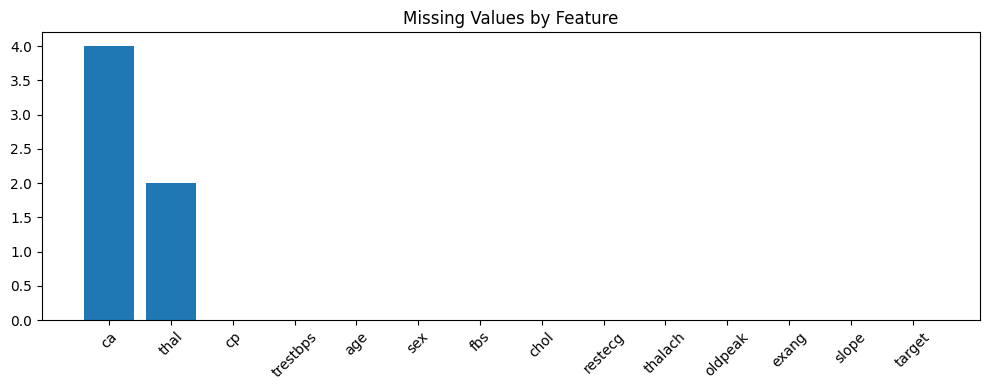

In [3]:
missing = raw.isna().sum().sort_values(ascending=False)
display(missing[missing > 0].to_frame('missing_count'))
plt.figure(figsize=(10,4))
plt.bar(missing.index, missing.values)
plt.xticks(rotation=45)
plt.title('Missing Values by Feature')
plt.tight_layout();

The source file uses `?` for missing values. Median imputation is applied to the few missing `ca` and `thal` entries, while the production pipeline also contains imputers to prevent training-serving inconsistency.

In [4]:
df = clean_data(raw)
print('Remaining missing values:', int(df.isna().sum().sum()))
print('Class counts:')
display(df[TARGET_COLUMN].value_counts().rename_axis('target').to_frame('count'))

Remaining missing values: 0
Class counts:


,count
target,
0,164
1,139


## 3. Class distribution and feature distributions

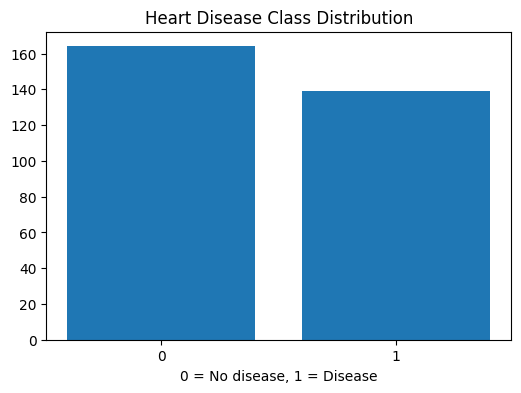

In [5]:
plt.figure(figsize=(6,4))
class_counts = df['target'].value_counts().sort_index()
plt.bar(class_counts.index.astype(str), class_counts.values)
plt.title('Heart Disease Class Distribution')
plt.xlabel('0 = No disease, 1 = Disease');

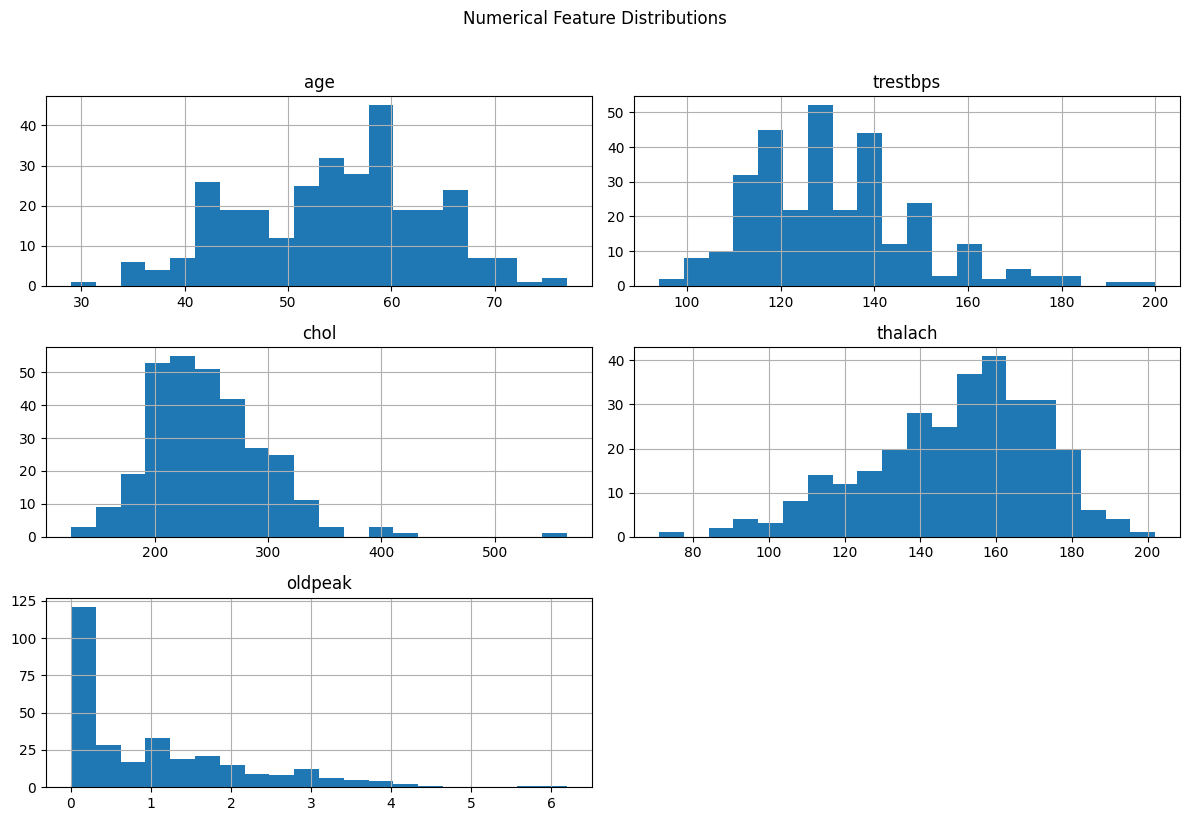

In [6]:
df[['age','trestbps','chol','thalach','oldpeak']].hist(bins=20, figsize=(12,8));
plt.suptitle('Numerical Feature Distributions', y=1.02);
plt.tight_layout();

## 4. Correlation and feature relationships

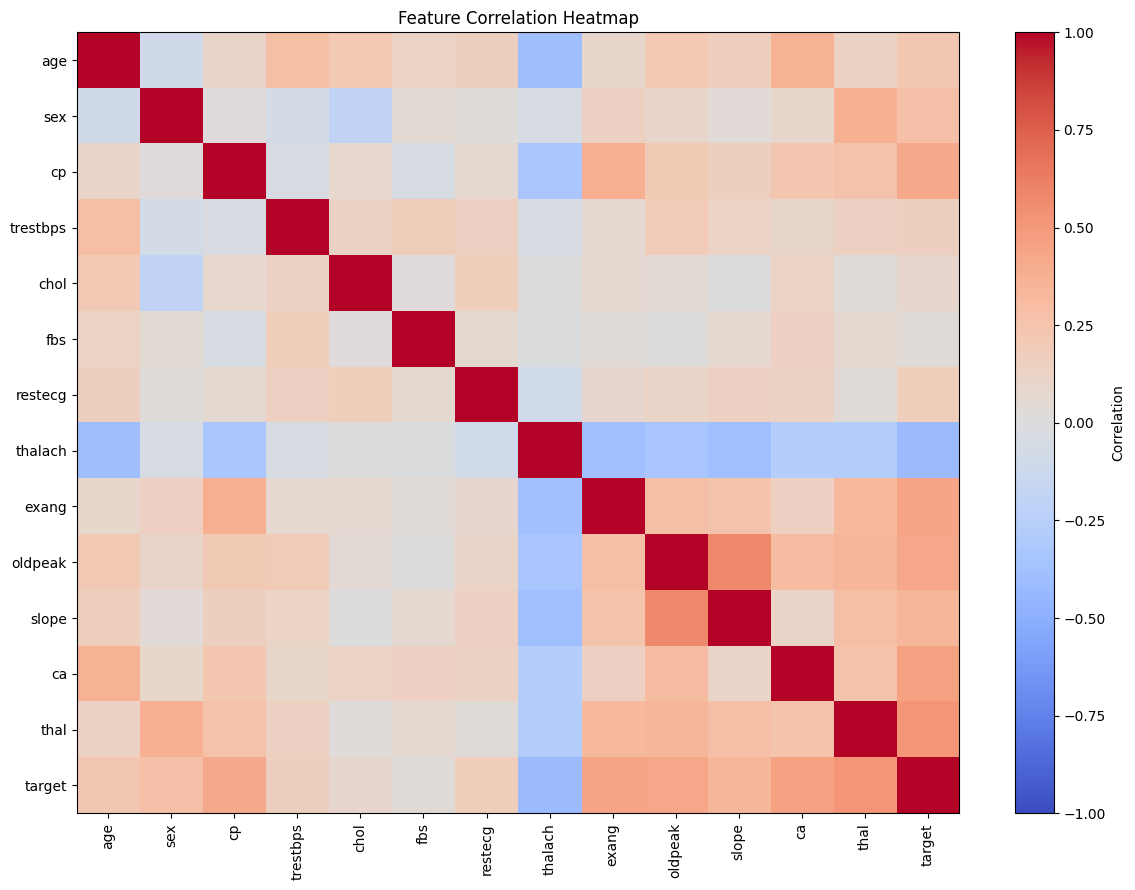

In [7]:
plt.figure(figsize=(12,9))
corr = df.corr(numeric_only=True)
img = plt.imshow(corr, aspect='auto', vmin=-1, vmax=1, cmap='coolwarm')
plt.colorbar(img, label='Correlation')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title('Feature Correlation Heatmap')
plt.tight_layout();

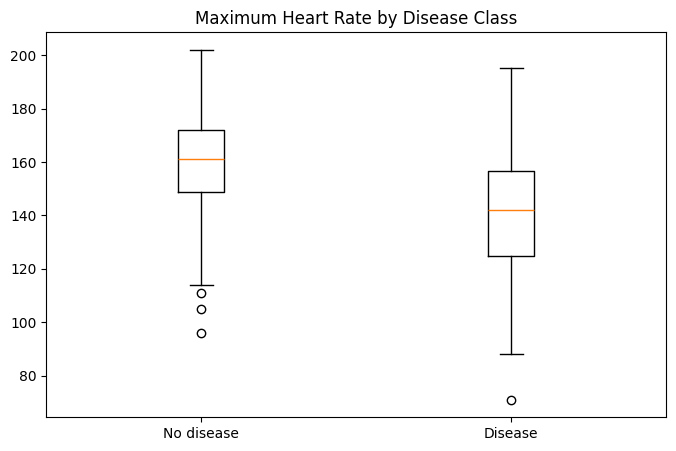

In [8]:
plt.figure(figsize=(8,5))
groups = [df.loc[df['target'] == value, 'thalach'] for value in sorted(df['target'].unique())]
plt.boxplot(groups, tick_labels=['No disease', 'Disease'])
plt.title('Maximum Heart Rate by Disease Class');

## 5. Reproducible modelling

The full comparison uses Logistic Regression and Random Forest, GridSearchCV, stratified cross-validation, ROC-AUC tuning, MLflow logging, and Joblib packaging.

In [9]:
# Run from the repository root for the complete tracked experiment:
# python -m src.train
# Then inspect the UI with:
# mlflow ui --backend-store-uri ./mlruns --port 5000

## 6. Interpretation and limitations

Document model comparison, potential bias, calibration, non-diagnostic use, monitoring, drift, and retraining decisions in the final report.